In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("DataPreprocessing1.csv")

print("Dataset shape:", df.shape)
print("First 5 rows:")
print(df.head())
print()

print("Date information:")
print(df.info())
print()

print("Description:")
print(df.describe())
print()

Dataset shape: (7043, 20)
First 5 rows:
   gender   age  sim_history_months  international_roaming_package  \
0       0  46.0                   1                              0   
1       1  38.0                  34                              1   
2       1  48.0                   2                              1   
3       1  58.0                  45                              1   
4       0  37.0                   2                              0   

   operator_cloud_space  night_internet_package  volte_calling_service  \
0                     1                       0                   -1.0   
1                     0                       1                   -1.0   
2                     1                       0                   -1.0   
3                     0                       1                    1.0   
4                     0                       0                   -1.0   

   superapp_social_network  superapp_financial_services  sim_card_type  \
0                   

Churn count: churn
0    5174
1    1869
Name: count, dtype: int64

Churn percent: churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


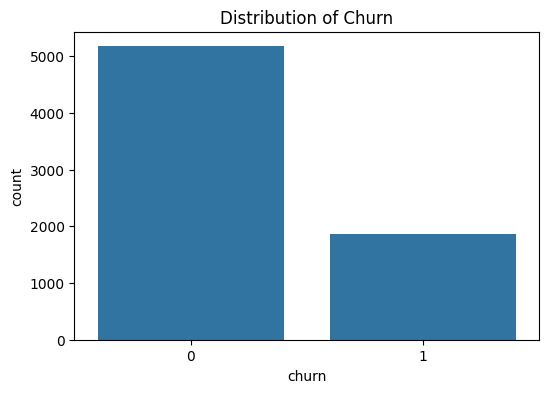

In [62]:
churncnt = df['churn'].value_counts()
churnpercent = df['churn'].value_counts(normalize=True) * 100
print("Churn count:", churncnt)
print()
print("Churn percent:", churnpercent)

plt.figure(figsize = (6, 4))
sns.countplot(data = df, x = 'churn')
plt.title('Distribution of Churn')
plt.show()

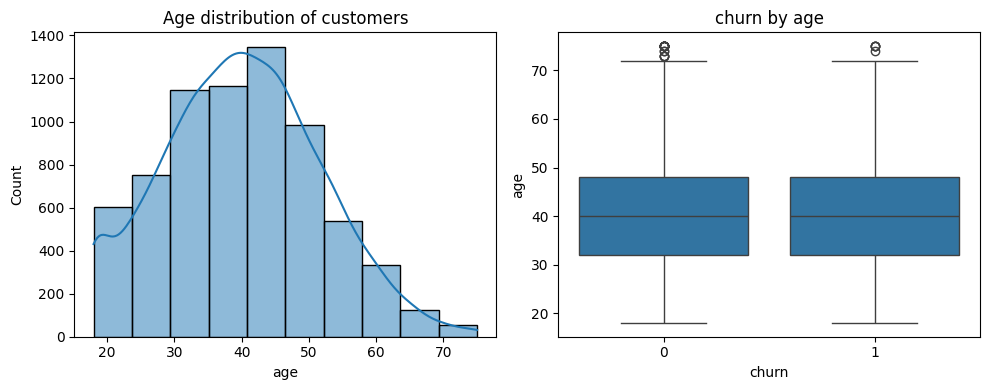

In [63]:
# Age

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['age'], bins=10, kde=True)
plt.title("Age distribution of customers")
plt.subplot(1,2,2)
sns.boxplot(x='churn', y='age', data=df)
plt.title("churn by age")
plt.tight_layout()
plt.show()


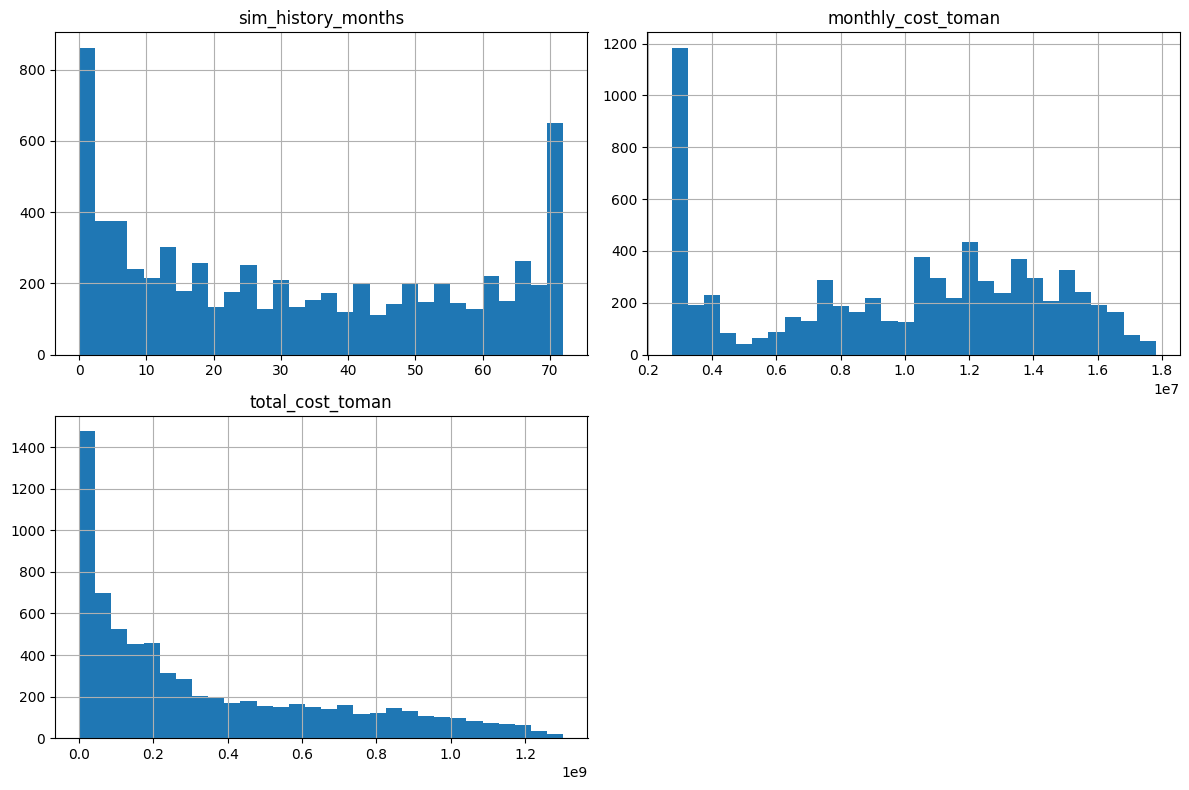

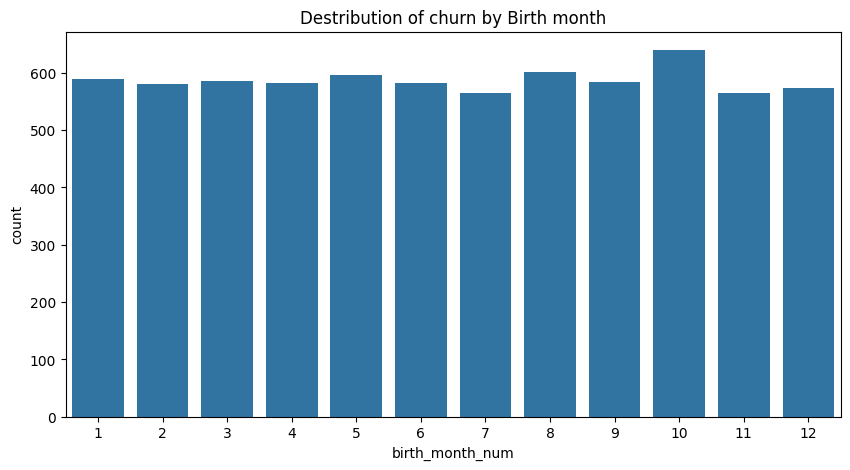

In [64]:
# Histograms

numeric_cols = ['sim_history_months', 'monthly_cost_toman', 'total_cost_toman']

angle = np.arctan2(df['birth_month_sin'], df['birth_month_cos'])
angle[angle < 0] += 2 * np.pi
df['birth_month_num'] = (angle / (2 * np.pi) * 12).round().astype(int) % 12
df['birth_month_num'] = df['birth_month_num'].replace(0, 12) 

df[numeric_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df, x = 'birth_month_num', order = range(1,13))
plt.title("Destribution of churn by Birth month")
plt.show()

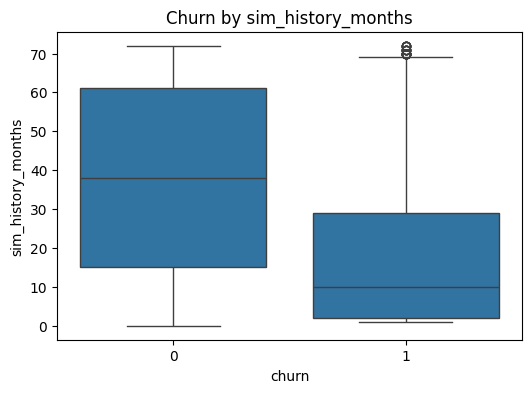

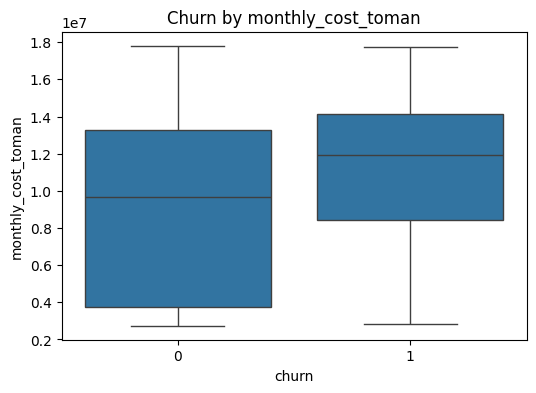

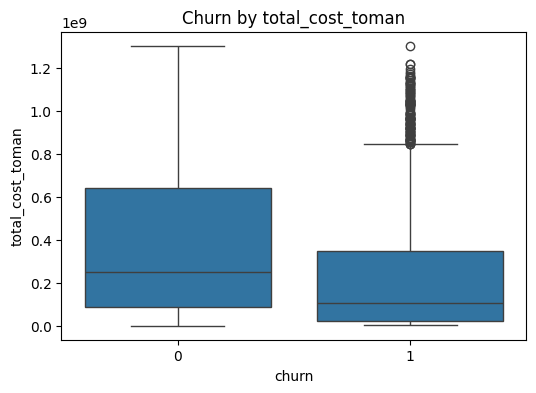

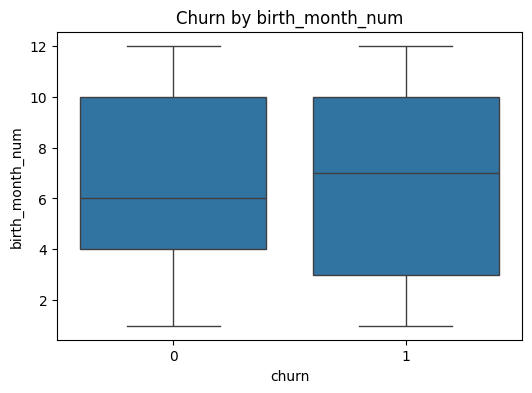

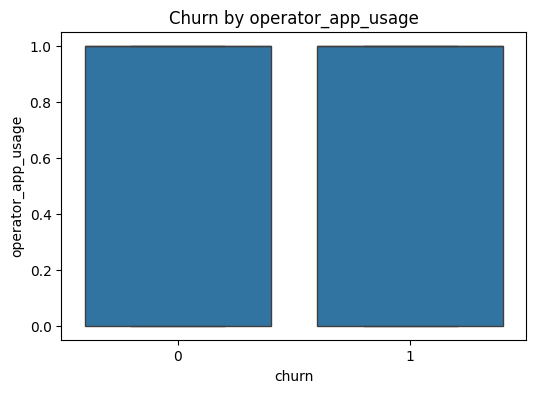

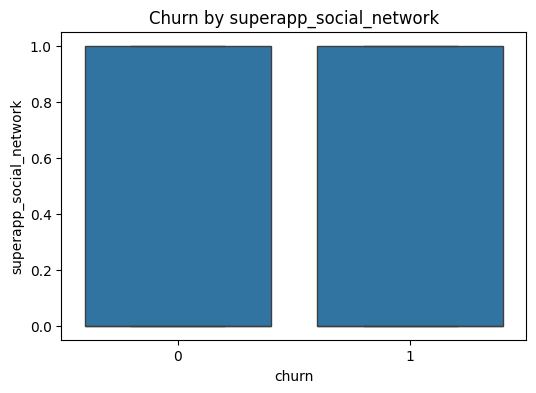

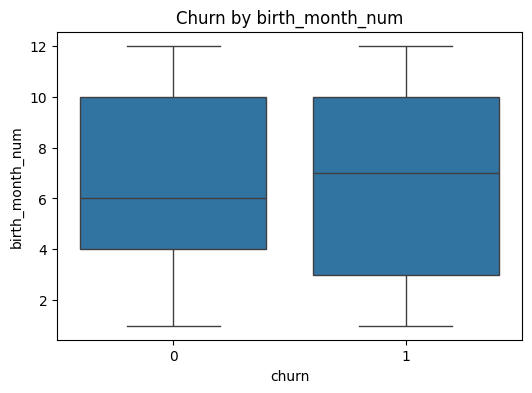

In [70]:
# Boxplots
numeric_cols += ['birth_month_num']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='churn', y=col)
    plt.title(f"Churn by {col}")
    plt.show()

gender
churn           0          1
gender                      
0       73.079128  26.920872
1       73.839662  26.160338


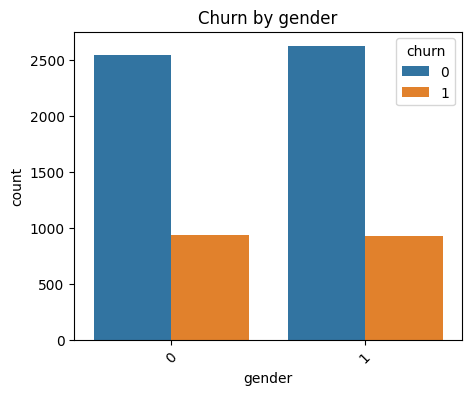


sim_card_type
churn                  0          1
sim_card_type                      
0              57.290323  42.709677
1              93.244949   6.755051


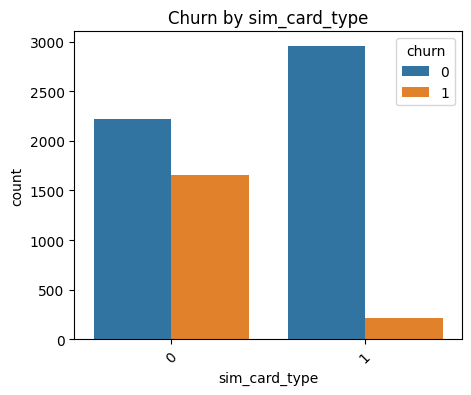


mobile_internet_generation
churn                               0          1
mobile_internet_generation                      
2G                          92.595020   7.404980
3G                          82.644628  17.355372
4G                          80.353982  19.646018
5G                          58.107235  41.892765


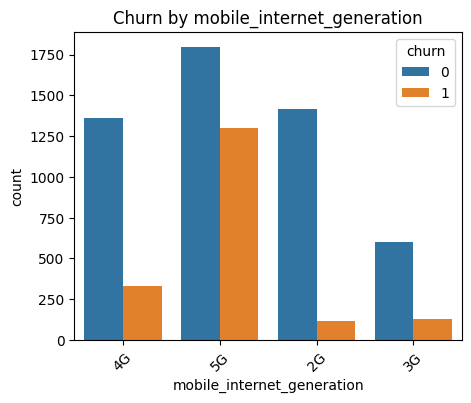


international_roaming_package
churn                                  0          1
international_roaming_package                      
0                              68.670382  31.329618
1                              85.388806  14.611194


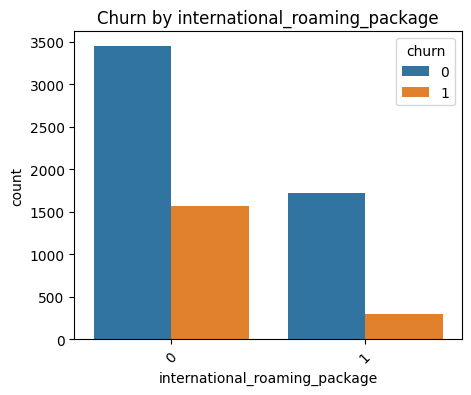


operator_cloud_space
churn                         0          1
operator_cloud_space                      
0                     70.827915  29.172085
1                     78.468506  21.531494


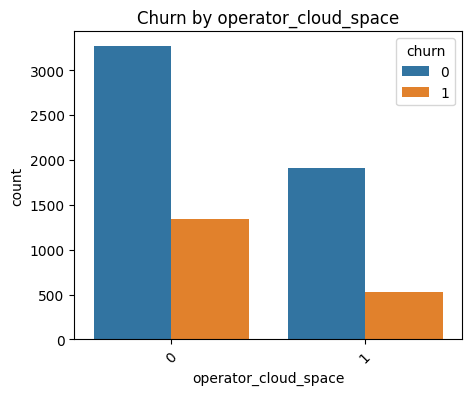


night_internet_package
churn                           0          1
night_internet_package                      
0                       71.348193  28.651807
1                       77.497936  22.502064


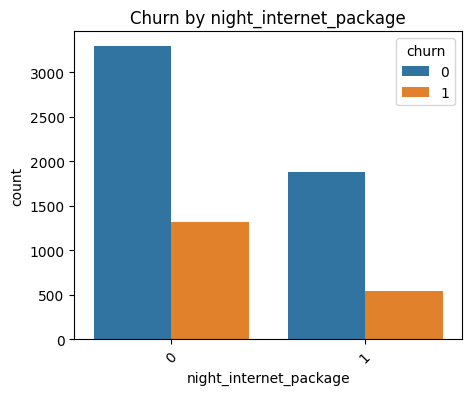


operator_app_usage
churn                       0          1
operator_app_usage                      
0                   83.669916  16.330084
1                   66.434908  33.565092


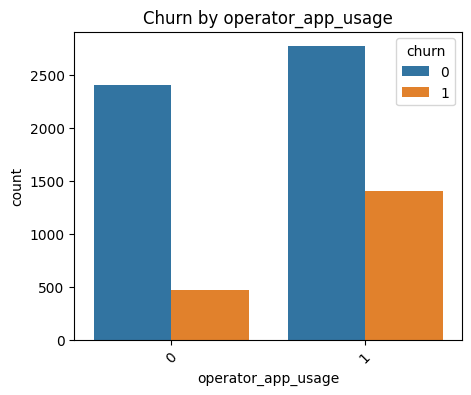

In [66]:
binary_cols = ['international_roaming_package', 'operator_cloud_space', 'night_internet_package','operator_app_usage']
categorical_cols = ['gender', 'sim_card_type']  # plus generation columns

# For generation, we can derive a single column
def get_generation(row):
    if row['gen_2G'] == 1:
        return '2G'
    elif row['gen_3G'] == 1:
        return '3G'
    elif row['gen_4G'] == 1:
        return '4G'
    elif row['gen_5G'] == 1:
        return '5G'
    else:
        return 'Unknown'

df['mobile_internet_generation'] = df.apply(get_generation, axis=1)
categorical_cols.append('mobile_internet_generation')

# Analyze each categorical variable against churn
for col in categorical_cols + binary_cols:
    print(f"{col}")
    cross = pd.crosstab(df[col], df['churn'], normalize='index') * 100
    print(cross)
    plt.figure(figsize=(5,4))
    sns.countplot(data=df, x=col, hue='churn')
    plt.title(f'Churn by {col}')
    plt.xticks(rotation=45)
    plt.show()
    print()

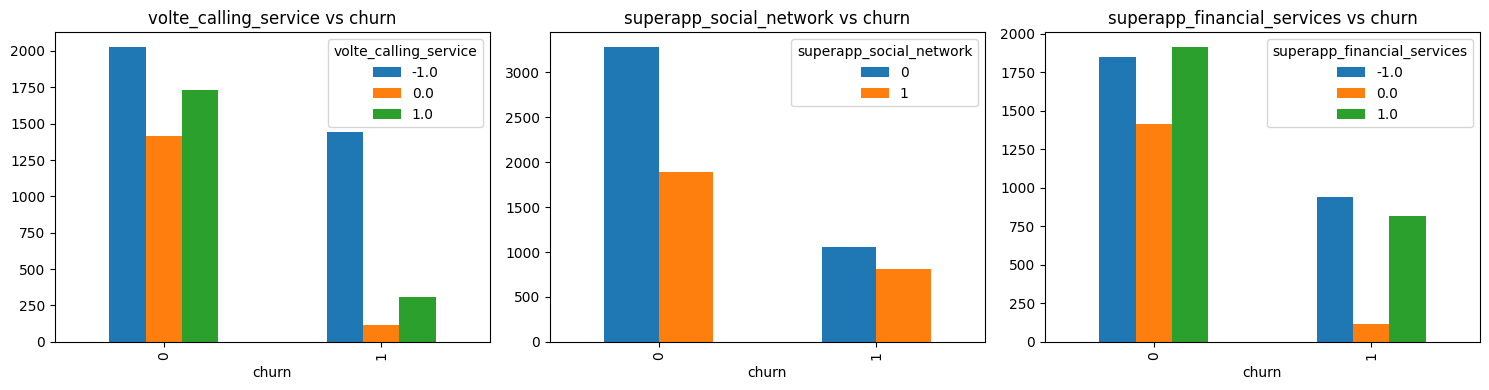

In [67]:
fig, axes = plt.subplots(1,3, figsize=(15,4))
cols_three = ['volte_calling_service', 'superapp_social_network', 'superapp_financial_services']
for i, col in enumerate(cols_three):
    pd.crosstab(df['churn'], df[col]).plot(kind='bar', ax=axes[i], legend=True)
    axes[i].set_title(f'{col} vs churn')
    axes[i].set_xlabel('churn')
plt.tight_layout()
plt.show()

In [68]:
numeric_cols += ['operator_app_usage', 'superapp_social_network']

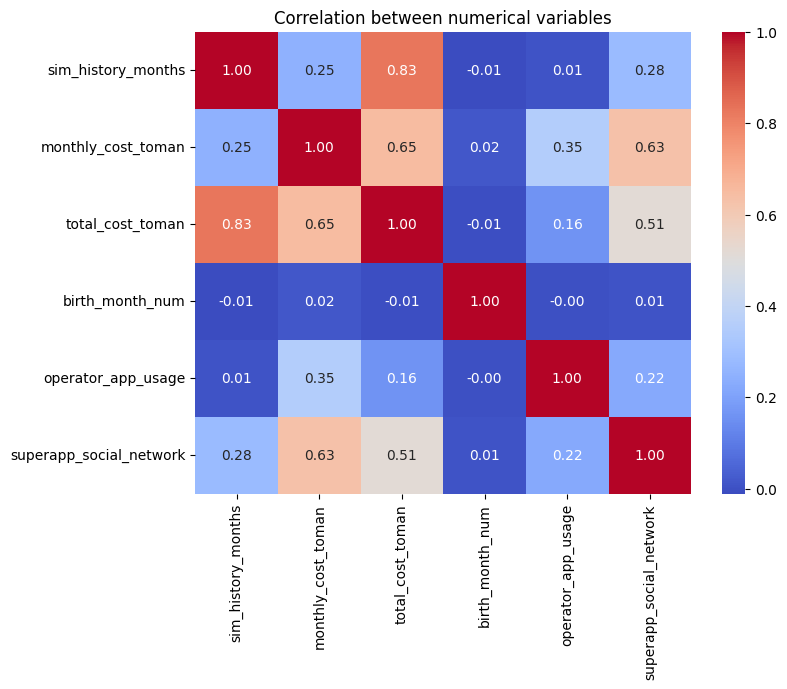

In [69]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot = True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation between numerical variables")
plt.show()